In [1]:
print('hi')

hi


In [2]:
!pip -q install scikit-learn git+https://github.com/facebookresearch/segment-anything.git

import os, json, pickle, random, warnings
import numpy as np
import pandas as pd
from PIL import Image
import cv2
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from segment_anything import sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    confusion_matrix, classification_report, roc_curve
)
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

  Preparing metadata (setup.py) ... done
Device: cuda


In [3]:
DATA_DIR = (
    "/kaggle/input/datasets/hiralisangani/breast-images-and-clinical/"
    "BrEaST-Lesions_USG-images_and_masks-Dec-15-2023/"
    "BrEaST-Lesions_USG-images_and_masks"
)

# EHR data - TWO versions for ablation
EHR_PKL            = "/kaggle/input/models/hiralisangani/breast-usg-ehr/pytorch/default/1/ehr_processed.pkl"           # With BIRADS (57-dim)
EHR_PKL_NO_BIRADS  = "/kaggle/input/models/hiralisangani/ehr-no-birads/pytorch/default/1/ehr_processed_no_birads.pkl" # Without BIRADS (56-dim)

# Global splits to prevent data leakage
GLOBAL_SPLITS_PATH = "/kaggle/input/datasets/hiralisangani/global-split/global_splits.json"

WORK_DIR = "/kaggle/working"
os.makedirs(WORK_DIR, exist_ok=True)

# --- MedSAM checkpoints ---
SAM_MODEL_TYPE = "vit_b"
SAM_BASE_CHECKPOINT = '/kaggle/input/models/hiralisangani/medsam_vit_b/pytorch/default/1/medsam_vit_b.pth'

# NEW: Fine-tuned checkpoint now includes encoder
SAM_FINETUNED_CHECKPOINT = '/kaggle/input/models/hiralisangani/medsam-seg/pytorch/default/1/medsam_breast_usg_best.pt'

SEED         = 42
N_FOLDS      = 5
BATCH_SIZE   = 16
LR           = 1e-3
EPOCHS       = 50
PATIENCE     = 8
SAM_FEAT_DIM = 256
IMG_OUT_DIM  = 128
EHR_HIDDEN   = 64
EHR_OUT_DIM  = 64
DROPOUT      = 0.3
BILINEAR_RANK = 32

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Config loaded. Device: {device}")
# rank for low-rank bilinear fusion

# --- Colours per fusion mode (consistent across all plots) ---
MODE_COLORS = {
    'image_only':      '#3498db',
    'ehr_only':        '#e67e22',
    'concat':          '#2ecc71',
    'gated':           '#e74c3c',
    'bilinear':        '#9b59b6',
    'cross_attention': '#1abc9c',
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print('Config OK ✓')

Config loaded. Device: cuda
Config OK ✓


In [4]:
with open(GLOBAL_SPLITS_PATH, 'r') as f:
    global_splits = json.load(f)

# For classification: use train_val for 5-fold CV, test for final evaluation
train_val_case_ids = global_splits['train_val']  # 201 cases
test_case_ids = global_splits['test']             # 51 cases

print(f"Global splits loaded:")
print(f"  Train+Val (for 5-fold CV): {len(train_val_case_ids)} cases")
print(f"  Test (held-out):           {len(test_case_ids)} cases")
print(f"  Total:                     {len(train_val_case_ids) + len(test_case_ids)} cases")

# Verify no overlap
assert len(set(train_val_case_ids) & set(test_case_ids)) == 0, "Data leakage detected!"
print("\\n[OK] No overlap between train_val and test sets")


Global splits loaded:
  Train+Val (for 5-fold CV): 201 cases
  Test (held-out):           51 cases
  Total:                     252 cases
\n[OK] No overlap between train_val and test sets


In [9]:
assert len(all_case_ids) == 252, f"Expected 252 cases, got {len(all_case_ids)}"
assert set(train_val_case_ids + test_case_ids) == set(all_case_ids), \
    "Mismatch: splits don't match EHR data cases!"
assert len(set(train_val_case_ids) & set(test_case_ids)) == 0, \
    "Data leakage: overlap detected!"

print(f"\nGlobal splits loaded:")
print(f"  Train+Val (for CV): {len(train_val_case_ids)} cases")
print(f"  Test (held-out):    {len(test_case_ids)} cases")
print(f"[OK] No overlap, all cases accounted for")


Global splits loaded:
  Train+Val (for CV): 201 cases
  Test (held-out):    51 cases
[OK] No overlap, all cases accounted for


In [6]:
# Load base MedSAM
sam_model = sam_model_registry[SAM_MODEL_TYPE](checkpoint=SAM_BASE_CHECKPOINT).to(device)

# Load fine-tuned weights (NOW INCLUDES ENCODER)
finetuned_ckpt = torch.load(SAM_FINETUNED_CHECKPOINT, map_location=device)

# Check if checkpoint includes encoder
if 'image_encoder' in finetuned_ckpt:
    sam_model.image_encoder.load_state_dict(finetuned_ckpt['image_encoder'])
    print("[OK] Loaded FINE-TUNED image encoder (domain-adapted to breast US)")
else:
    print("[WARN] Checkpoint does not include image_encoder - using pre-trained MedSAM encoder")
    print("       Re-train segmentation with encoder unfrozen for best results!")

sam_model.prompt_encoder.load_state_dict(finetuned_ckpt['prompt_encoder'])
sam_model.mask_decoder.load_state_dict(finetuned_ckpt['mask_decoder'])

sam_model.eval()
for p in sam_model.parameters():
    p.requires_grad = False

resize = ResizeLongestSide(sam_model.image_encoder.img_size)
print(f"MedSAM loaded. Encoder size: {sam_model.image_encoder.img_size}")


[OK] Loaded FINE-TUNED image encoder (domain-adapted to breast US)
MedSAM loaded. Encoder size: 1024


In [5]:
# ============================================================
# LOAD EHR DATA - BOTH VERSIONS FOR ABLATION
# ============================================================
with open(EHR_PKL, 'rb') as f:
    ehr_data = pickle.load(f)

feature_records = ehr_data['feature_records']
EHR_DIM = ehr_data['feat_dim']

all_case_ids = sorted([cid for cid in feature_records.keys() 
                       if cid in train_val_case_ids or cid in test_case_ids])
all_labels = np.array([feature_records[c]['label'] for c in all_case_ids])

print(f"EHR data (with BIRADS): {len(feature_records)} samples, {EHR_DIM} features")
print(f"Class balance: {Counter(all_labels.tolist())}")
print(f"  0=benign ({(all_labels==0).sum()}), 1=malignant ({(all_labels==1).sum()})")

# Version 2: Without BIRADS (for ablation)
try:
    with open(EHR_PKL_NO_BIRADS, 'rb') as f:
        ehr_data_no_birads = pickle.load(f)
    feature_records_no_birads = ehr_data_no_birads['feature_records']
    EHR_DIM_NO_BIRADS = ehr_data_no_birads['feat_dim']
    print(f"\nEHR data (no BIRADS): {len(feature_records_no_birads)} samples, {EHR_DIM_NO_BIRADS} features")
    HAS_NO_BIRADS = True
except FileNotFoundError:
    print("\n[WARN] ehr_processed_no_birads.pkl not found - BIRADS ablation will be skipped")
    HAS_NO_BIRADS = False
    feature_records_no_birads = None
    EHR_DIM_NO_BIRADS = None

EHR data (with BIRADS): 252 samples, 57 features
Class balance: Counter({0: 154, 1: 98})
  0=benign (154), 1=malignant (98)

EHR data (no BIRADS): 252 samples, 56 features


In [7]:
# ============================================================
# PRE-COMPUTE IMAGE FEATURES - WITH FINE-TUNED ENCODER
# ============================================================

print("Loading MedSAM ViT-B...")
sam_model = sam_model_registry[SAM_MODEL_TYPE](checkpoint=SAM_BASE_CHECKPOINT).to(device)

# Load fine-tuned weights (NOW INCLUDES ENCODER)
finetuned_ckpt = torch.load(SAM_FINETUNED_CHECKPOINT, map_location=device)

if 'image_encoder' in finetuned_ckpt:
    sam_model.image_encoder.load_state_dict(finetuned_ckpt['image_encoder'])
    print("[OK] Loaded FINE-TUNED image encoder (domain-adapted to breast US)")
else:
    print("[INFO] Checkpoint does not include image_encoder - using pre-trained MedSAM encoder")

sam_model.prompt_encoder.load_state_dict(finetuned_ckpt['prompt_encoder'])
sam_model.mask_decoder.load_state_dict(finetuned_ckpt['mask_decoder'])
print("[OK] Loaded fine-tuned prompt_encoder + mask_decoder")

sam_model.eval()
for p in sam_model.parameters():
    p.requires_grad = False

resize_tf = ResizeLongestSide(sam_model.image_encoder.img_size)
FEAT_MAP_SIZE = 64
SEG_INPUT_SIZE = 512


def mask_to_bbox(mask_np):
    """Tight bounding box [x1, y1, x2, y2] from binary mask."""
    ys, xs = np.where(mask_np > 0)
    if len(xs) == 0:
        return None
    return [int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())]


def extract_morphological_features(mask_np):
    """8 shape descriptors from a binary mask."""
    H, W = mask_np.shape
    total_area = H * W
    area = float(mask_np.sum())

    if area == 0:
        return np.zeros(8, dtype=np.float32)

    contours, _ = cv2.findContours(
        mask_np.copy().astype(np.uint8),
        cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return np.zeros(8, dtype=np.float32)

    cnt = max(contours, key=cv2.contourArea)
    perimeter = cv2.arcLength(cnt, True)
    circularity = 4 * np.pi * area / (perimeter ** 2 + 1e-6)

    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = max(w, h) / (min(w, h) + 1e-6)

    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = area / (hull_area + 1e-6)

    if len(cnt) >= 5:
        _, (ma, MA), _ = cv2.fitEllipse(cnt)
        eccentricity = np.sqrt(1 - (min(ma, MA) ** 2) / (max(ma, MA) ** 2 + 1e-6))
    else:
        eccentricity = 0.0

    equiv_diam_norm = np.sqrt(4 * area / np.pi) / np.sqrt(total_area)
    compactness = perimeter ** 2 / (4 * np.pi * area + 1e-6)

    return np.array([
        area / total_area, perimeter / np.sqrt(total_area),
        circularity, aspect_ratio, solidity,
        eccentricity, equiv_diam_norm, compactness,
    ], dtype=np.float32)


def extract_intensity_features(img_np, mask_np):
    """12 intensity / gradient / texture features inside the lesion."""
    if mask_np.sum() == 0:
        return np.zeros(12, dtype=np.float32)

    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    roi_px = gray[mask_np > 0].astype(np.float64)

    mean_v = roi_px.mean() / 255.0
    std_v  = roi_px.std()  / 255.0
    
    try:
        from scipy.stats import skew, kurtosis
        skew_v = float(skew(roi_px))
        if np.isnan(skew_v): skew_v = 0.0
        kurt_v = float(kurtosis(roi_px))
        if np.isnan(kurt_v): kurt_v = 0.0
    except Exception:
        skew_v, kurt_v = 0.0, 0.0

    p10 = np.percentile(roi_px, 10) / 255.0
    p90 = np.percentile(roi_px, 90) / 255.0
    iqr = (np.percentile(roi_px, 75) - np.percentile(roi_px, 25)) / 255.0

    bg_px = gray[mask_np == 0].astype(np.float64)
    contrast = mean_v - (bg_px.mean() / 255.0 if len(bg_px) > 0 else mean_v)

    hist, _ = np.histogram(roi_px, bins=32, range=(0, 256))
    hist = hist / (hist.sum() + 1e-6)
    entropy = -np.sum(hist * np.log2(hist + 1e-10)) / 5.0

    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.sqrt(sobelx ** 2 + sobely ** 2)
    edge_mean = grad_mag[mask_np > 0].mean() / 255.0

    boundary = cv2.dilate(mask_np.astype(np.uint8), np.ones((3, 3), np.uint8)) - mask_np
    boundary_grad = grad_mag[boundary > 0].mean() / 255.0 if boundary.sum() > 0 else edge_mean

    return np.array([
        mean_v, std_v, skew_v, kurt_v,
        p10, p90, iqr, contrast,
        entropy, edge_mean, boundary_grad,
        std_v / (mean_v + 1e-6),
    ], dtype=np.float32)


@torch.no_grad()
def precompute_sam_features(sam_model, data_dir, case_ids, device):
    """Feature extraction pipeline."""
    features = {}
    pred_masks_orig = {}
    dice_scores = []

    for cid in tqdm(case_ids, desc="Module 1 -> 2 pipeline"):
        img_orig = np.array(Image.open(os.path.join(data_dir, f'{cid}.png')).convert('RGB'))
        gt_msk_orig = np.array(Image.open(os.path.join(data_dir, f'{cid}_tumor.png')).convert('L'))
        gt_msk_orig = (gt_msk_orig > 0).astype(np.uint8)
        H_orig, W_orig = img_orig.shape[:2]

        img = cv2.resize(img_orig, (SEG_INPUT_SIZE, SEG_INPUT_SIZE), interpolation=cv2.INTER_LINEAR)
        gt_msk = cv2.resize(gt_msk_orig, (SEG_INPUT_SIZE, SEG_INPUT_SIZE), interpolation=cv2.INTER_NEAREST)
        H, W = SEG_INPUT_SIZE, SEG_INPUT_SIZE

        img_resized = resize_tf.apply_image(img)
        h_new, w_new = img_resized.shape[:2]

        img_t = torch.as_tensor(img_resized, device=device).permute(2, 0, 1).float()
        img_t = (img_t - sam_model.pixel_mean) / sam_model.pixel_std
        img_t = sam_model.preprocess(img_t.unsqueeze(0))

        image_embedding = sam_model.image_encoder(img_t)

        bbox = mask_to_bbox(gt_msk)
        if bbox is None:
            bbox = [0, 0, W - 1, H - 1]
        box_t = torch.tensor(bbox, device=device, dtype=torch.float32)
        box_t = resize_tf.apply_boxes_torch(box_t[None, :], (H, W))

        sparse_emb, dense_emb = sam_model.prompt_encoder(points=None, boxes=box_t[:, None, :], masks=None)
        low_res_logits, _ = sam_model.mask_decoder(
            image_embeddings=image_embedding,
            image_pe=sam_model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_emb,
            dense_prompt_embeddings=dense_emb,
            multimask_output=False,
        )

        up_logits = F.interpolate(low_res_logits, size=(H, W), mode='bilinear', align_corners=False)
        pred_msk = (torch.sigmoid(up_logits[0, 0]) >= 0.5).cpu().numpy().astype(np.uint8)

        intersection = (pred_msk * gt_msk).sum()
        dice = (2 * intersection) / (pred_msk.sum() + gt_msk.sum() + 1e-6)
        dice_scores.append(dice)

        pred_msk_full = cv2.resize(pred_msk, (W_orig, H_orig), interpolation=cv2.INTER_NEAREST)
        pred_masks_orig[cid] = pred_msk_full

        # Feature extraction
        img_size = sam_model.image_encoder.img_size
        pred_msk_resized = cv2.resize(pred_msk, (w_new, h_new), interpolation=cv2.INTER_NEAREST)
        msk_padded = np.zeros((img_size, img_size), dtype=np.uint8)
        msk_padded[:h_new, :w_new] = pred_msk_resized
        msk_64 = cv2.resize(msk_padded, (FEAT_MAP_SIZE, FEAT_MAP_SIZE), interpolation=cv2.INTER_NEAREST)
        msk_64_t = torch.from_numpy(msk_64).float().to(device)

        feat_map = image_embedding[0]
        C = feat_map.shape[0]

        if msk_64_t.sum() > 0:
            mask = msk_64_t.unsqueeze(0)
            bg_mask = 1.0 - mask
            lesion_mean = (feat_map * mask).sum(dim=(1, 2)) / mask.sum()
            diff = feat_map - lesion_mean.unsqueeze(1).unsqueeze(2)
            lesion_std = torch.sqrt((diff ** 2 * mask).sum(dim=(1, 2)) / mask.sum() + 1e-6)
            masked_feat = feat_map * mask + (1 - mask) * (-1e9)
            lesion_max = masked_feat.amax(dim=(1, 2))
            bg_mean = (feat_map * bg_mask).sum(dim=(1, 2)) / bg_mask.sum() if bg_mask.sum() > 0 else torch.zeros(C, device=device)
            contrast = lesion_mean - bg_mean
            sam_feats = torch.cat([lesion_mean, lesion_std, lesion_max, contrast])
        else:
            gap = feat_map.mean(dim=(1, 2))
            sam_feats = torch.cat([gap, torch.zeros_like(gap), gap, torch.zeros_like(gap)])

        morph = extract_morphological_features(pred_msk)
        intensity = extract_intensity_features(img, pred_msk)

        all_feats = torch.cat([sam_feats.cpu(), torch.from_numpy(morph), torch.from_numpy(intensity)])
        features[cid] = all_feats

    return features, pred_masks_orig, dice_scores


sam_features, predicted_masks, seg_dices = precompute_sam_features(sam_model, DATA_DIR, all_case_ids, device)
IMG_FEAT_DIM = sam_features[all_case_ids[0]].shape[0]

dices = np.array(seg_dices)
print(f"\n{'='*60}")
print(f"Module 1 Segmentation Quality")
print(f"{'='*60}")
print(f"  Cases processed: {len(sam_features)}")
print(f"  Dice (mean+/-std): {dices.mean():.4f} +/- {dices.std():.4f}")
print(f"  Dice (min/max):  {dices.min():.4f} / {dices.max():.4f}")
print(f"  Feature dim: {IMG_FEAT_DIM}")

del sam_model
torch.cuda.empty_cache()


def extract_roi(img_np, mask_np, pad_frac=0.15, out_size=224):
    H, W = mask_np.shape[:2]
    ys, xs = np.where(mask_np > 0)
    if len(xs) == 0:
        roi = img_np
    else:
        x1, y1, x2, y2 = xs.min(), ys.min(), xs.max(), ys.max()
        bw, bh = x2 - x1, y2 - y1
        px, py = int(bw * pad_frac), int(bh * pad_frac)
        x1 = max(0, x1 - px); y1 = max(0, y1 - py)
        x2 = min(W, x2 + px); y2 = min(H, y2 + py)
        roi = img_np[y1:y2, x1:x2]
    return cv2.resize(roi, (out_size, out_size), interpolation=cv2.INTER_LINEAR)

Loading MedSAM ViT-B...
[OK] Loaded FINE-TUNED image encoder (domain-adapted to breast US)
[OK] Loaded fine-tuned prompt_encoder + mask_decoder


Module 1 -> 2 pipeline: 100%|██████████| 252/252 [01:16<00:00,  3.29it/s]


Module 1 Segmentation Quality
  Cases processed: 252
  Dice (mean+/-std): 0.8517 +/- 0.0572
  Dice (min/max):  0.4369 / 0.9217
  Feature dim: 1044


In [8]:
# ============================================================
# DATASET - returns (pre-computed SAM features, EHR vector, label)
# ============================================================
class MultimodalBreastDataset(Dataset):
    """Lightweight dataset returning pre-computed feature vectors."""
    def __init__(self, case_ids, sam_features, feature_records):
        self.case_ids = case_ids
        self.sam_feat = sam_features
        self.feat = feature_records

    def __len__(self):
        return len(self.case_ids)

    def __getitem__(self, idx):
        cid = self.case_ids[idx]
        img_feat = self.sam_feat[cid]
        ehr = torch.from_numpy(self.feat[cid]['features'])
        label = torch.tensor(self.feat[cid]['label'], dtype=torch.float32)
        return img_feat, ehr, label, cid

print('MultimodalBreastDataset defined')

MultimodalBreastDataset defined


In [9]:
# ============================================================
# MODEL ARCHITECTURES - 6 fusion modes + BIRADS-excluded ablations
# ============================================================

class EHREncoder(nn.Module):
    """Two-layer MLP encoder for tabular clinical features.
    Supports variable input dimensions for BIRADS ablation."""
    def __init__(self, input_dim, hidden_dim=64, output_dim=64, dropout=0.3):
        super().__init__()
        self.input_dim = input_dim
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)


class MammoAssistClassifier(nn.Module):
    """Multimodal breast cancer classifier with pre-computed image features."""
    def __init__(self, ehr_dim, img_feat_dim, fusion='gated',
                 img_out=IMG_OUT_DIM, ehr_hidden=EHR_HIDDEN,
                 ehr_out=EHR_OUT_DIM, dropout=DROPOUT,
                 bilinear_rank=BILINEAR_RANK):
        super().__init__()
        self.fusion_type = fusion

        self.img_proj = nn.Sequential(
            nn.Linear(img_feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, img_out),
            nn.ReLU(),
        )

        self.ehr_encoder = EHREncoder(ehr_dim, ehr_hidden, ehr_out, dropout)

        if fusion == 'gated':
            self.gate = nn.Linear(ehr_out, img_out)
            cls_in = img_out + ehr_out
        elif fusion == 'concat':
            cls_in = img_out + ehr_out
        elif fusion == 'bilinear':
            self.U = nn.Linear(img_out, bilinear_rank, bias=False)
            self.V = nn.Linear(ehr_out, bilinear_rank, bias=False)
            self.P = nn.Linear(bilinear_rank, 64)
            cls_in = 64 + img_out + ehr_out
        elif fusion == 'cross_attention':
            self.ehr_proj_ca = nn.Linear(ehr_out, img_out)
            self.cross_attn = nn.MultiheadAttention(img_out, num_heads=4, batch_first=True, dropout=dropout)
            self.ln_ca = nn.LayerNorm(img_out)
            cls_in = img_out + ehr_out
        elif fusion == 'image_only':
            cls_in = img_out
        elif fusion == 'ehr_only':
            cls_in = ehr_out
        else:
            raise ValueError(f'Unknown fusion: {fusion}')

        self.classifier = nn.Sequential(
            nn.Linear(cls_in, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, img_features, ehr_features):
        z_img = self.img_proj(img_features)
        z_ehr = self.ehr_encoder(ehr_features)

        if self.fusion_type == 'gated':
            gate = torch.sigmoid(self.gate(z_ehr))
            z = torch.cat([z_img * gate, z_ehr], dim=1)
        elif self.fusion_type == 'concat':
            z = torch.cat([z_img, z_ehr], dim=1)
        elif self.fusion_type == 'bilinear':
            u = self.U(z_img)
            v = self.V(z_ehr)
            bi = torch.relu(self.P(u * v))
            z = torch.cat([bi, z_img, z_ehr], dim=1)
        elif self.fusion_type == 'cross_attention':
            ehr_tok = self.ehr_proj_ca(z_ehr).unsqueeze(1)
            img_tok = z_img.unsqueeze(1)
            tokens = torch.cat([img_tok, ehr_tok], dim=1)
            attn_out, _ = self.cross_attn(tokens, tokens, tokens)
            z_img_ref = self.ln_ca(attn_out[:, 0, :] + z_img)
            z = torch.cat([z_img_ref, z_ehr], dim=1)
        elif self.fusion_type == 'image_only':
            z = z_img
        elif self.fusion_type == 'ehr_only':
            z = z_ehr

        return self.classifier(z).squeeze(-1)

print('MammoAssistClassifier defined')
print(f'Image feature dim:  {IMG_FEAT_DIM} -> {IMG_OUT_DIM}')
print(f'EHR feature dim:    {EHR_DIM} -> {EHR_OUT_DIM}')

MammoAssistClassifier defined
Image feature dim:  1044 -> 128
EHR feature dim:    57 -> 64


In [10]:
# ============================================================
# TRAINING & EVALUATION HELPERS
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, n = 0.0, 0
    for img_feat, ehr, labels, _ in loader:
        img_feat = img_feat.to(device)
        ehr = ehr.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(img_feat, ehr)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
        n += len(labels)
    return total_loss / max(n, 1)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_probs, all_labels, all_cids = [], [], []
    total_loss, n = 0.0, 0
    criterion = nn.BCEWithLogitsLoss()

    for img_feat, ehr, labels, cids in loader:
        img_feat = img_feat.to(device)
        ehr = ehr.to(device)
        labels = labels.to(device)

        logits = model(img_feat, ehr)
        loss = criterion(logits, labels)
        total_loss += loss.item() * len(labels)
        n += len(labels)

        all_probs.extend(torch.sigmoid(logits).cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())
        all_cids.extend(cids)

    probs = np.array(all_probs)
    labels = np.array(all_labels)
    preds = (probs >= 0.5).astype(int)

    metrics = {
        'loss': total_loss / max(n, 1),
        'auc': roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else 0.0,
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, zero_division=0),
        'sensitivity': (preds[labels == 1].sum() / max(labels.sum(), 1)),
        'specificity': ((1 - preds[labels == 0]).sum() / max((1 - labels).sum(), 1)),
    }
    return metrics, probs, labels, all_cids

print('Training helpers defined')

Training helpers defined


In [11]:
# ============================================================
# BIRADS-ONLY BASELINE
# ============================================================
birads_map_inv = {'1': 0, '2': 1, '3': 2, '4a': 3, '4b': 4, '4c': 5, '5': 6}

birads_scores = np.array([birads_map_inv[feature_records[c]['birads']] for c in all_case_ids])

birads_preds = (birads_scores >= 3).astype(int)
birads_probs = birads_scores / 6.0

birads_auc = roc_auc_score(all_labels, birads_probs)
birads_acc = accuracy_score(all_labels, birads_preds)
birads_f1 = f1_score(all_labels, birads_preds)
birads_sens = birads_preds[all_labels == 1].sum() / all_labels.sum()
birads_spec = (1 - birads_preds[all_labels == 0]).sum() / (1 - all_labels).sum()

print('BIRADS-Only Baseline (threshold >= 4a)')
print('=' * 50)
print(f'  AUC:         {birads_auc:.4f}')
print(f'  Accuracy:    {birads_acc:.4f}')
print(f'  F1:          {birads_f1:.4f}')
print(f'  Sensitivity: {birads_sens:.4f}')
print(f'  Specificity: {birads_spec:.4f}')

BIRADS-Only Baseline (threshold >= 4a)
  AUC:         0.9298
  Accuracy:    0.6548
  F1:          0.6926
  Sensitivity: 1.0000
  Specificity: 0.4351


In [15]:
# ============================================================
# 5-FOLD STRATIFIED CV - ALL FUSION MODES + BIRADS ABLATION
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix
import numpy as np
import torch
import torch.nn as nn

# ============================================================
# Metrics
# ============================================================

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    dice = (2 * tp) / (2 * tp + fp + fn + 1e-8)
    f1 = dice

    return {
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'dice': dice,
        'f1': f1
    }


# ============================================================
# Define ablation modes
# ============================================================

FUSION_MODES = ['image_only', 'ehr_only', 'concat', 'gated', 'bilinear', 'cross_attention']

if HAS_NO_BIRADS:
    ABLATION_MODES_NO_BIRADS = ['ehr_only_no_birads', 'concat_no_birads', 'cross_attention_no_birads']
    ALL_ABLATION_MODES = FUSION_MODES + ABLATION_MODES_NO_BIRADS
else:
    ALL_ABLATION_MODES = FUSION_MODES

print(f"Running {len(ALL_ABLATION_MODES)} ablation experiments:")
for mode in ALL_ABLATION_MODES:
    print(f"  - {mode}")


def get_ehr_data_for_mode(mode):
    if 'no_birads' in mode:
        return feature_records_no_birads, EHR_DIM_NO_BIRADS
    return feature_records, EHR_DIM


# ============================================================
# Prepare CV
# ============================================================

train_val_labels = np.array([feature_records[c]['label'] for c in train_val_case_ids])
train_val_arr = np.array(train_val_case_ids)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

results = {
    mode: {m: [] for m in ['auc', 'accuracy', 'f1', 'sensitivity', 'specificity', 'dice']}
    for mode in ALL_ABLATION_MODES
}

fold_predictions = {mode: [] for mode in ALL_ABLATION_MODES}

training_curves = {
    mode: {'epoch': [], 'train_loss': [], 'val_auc': []}
    for mode in ALL_ABLATION_MODES
}


# ============================================================
# CV Loop
# ============================================================

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(train_val_arr, train_val_labels)):
    
    train_ids = train_val_arr[train_idx].tolist()
    val_ids = train_val_arr[val_idx].tolist()

    print(f'\n{"="*60}')
    print(f'FOLD {fold_idx + 1}/{N_FOLDS} (train={len(train_ids)}, val={len(val_ids)})')
    print('=' * 60)

    train_labels_fold = train_val_labels[train_idx]

    for mode in ALL_ABLATION_MODES:
        print(f'\n  Training [{mode}] ...')

        feat_recs, ehr_dim = get_ehr_data_for_mode(mode)
        base_mode = mode.replace('_no_birads', '')

        train_ds = MultimodalBreastDataset(train_ids, sam_features, feat_recs)
        val_ds = MultimodalBreastDataset(val_ids, sam_features, feat_recs)

        train_loader = DataLoader(
            train_ds,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=0,
            pin_memory=True,
            drop_last=True   # ✅ FIXED BatchNorm issue
        )

        val_loader = DataLoader(
            val_ds,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,
            pin_memory=True
        )

        pos_weight = torch.tensor(
            [(train_labels_fold == 0).sum() / max((train_labels_fold == 1).sum(), 1)],
            dtype=torch.float32
        ).to(device)

        model = MammoAssistClassifier(
            ehr_dim, IMG_FEAT_DIM,
            fusion=base_mode,
            dropout=DROPOUT
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=3, min_lr=1e-6
        )
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        best_auc, bad_epochs = 0.0, 0
        best_state = None

        # ====================================================
        # Training Loop
        # ====================================================
        for epoch in range(1, EPOCHS + 1):

            tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)

            val_metrics, val_probs, val_lbls, val_cids = evaluate(model, val_loader)

            scheduler.step(val_metrics['auc'])

            if fold_idx == 0:
                training_curves[mode]['epoch'].append(epoch)
                training_curves[mode]['train_loss'].append(tr_loss)
                training_curves[mode]['val_auc'].append(val_metrics['auc'])

            if val_metrics['auc'] > best_auc + 1e-4:
                best_auc = val_metrics['auc']
                bad_epochs = 0
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            else:
                bad_epochs += 1
                if bad_epochs >= PATIENCE:
                    break

        # ====================================================
        # Load best model
        # ====================================================
        if best_state is not None:
            model.load_state_dict(best_state)
            model.to(device)

        val_metrics, val_probs, val_lbls, val_cids = evaluate(model, val_loader)

        # Compute Dice etc explicitly (if not inside evaluate)
        extra_metrics = compute_metrics(val_lbls, val_probs)
        val_metrics.update(extra_metrics)

        # Save results
        for m in results[mode]:
            results[mode][m].append(val_metrics[m])

        fold_predictions[mode].append({
            'cids': val_cids,
            'probs': val_probs,
            'labels': val_lbls
        })

        # ====================================================
        # PRINT METRICS ✅
        # ====================================================
        print(
            f'    AUC={val_metrics["auc"]:.4f} | '
            f'Acc={val_metrics["accuracy"]:.4f} | '
            f'Sens={val_metrics["sensitivity"]:.4f} | '
            f'Spec={val_metrics["specificity"]:.4f} | '
            f'Dice={val_metrics["dice"]:.4f} '
            f'(best AUC={best_auc:.4f}, stopped ep {epoch})'
        )

        del model, optimizer, scheduler, criterion
        torch.cuda.empty_cache()

    # ========================================================
    # Fold summary
    # ========================================================
    print("\n  Fold Summary:")
    for mode in ALL_ABLATION_MODES:
        print(
            f"    {mode:25s} | "
            f"AUC={results[mode]['auc'][-1]:.4f} | "
            f"Acc={results[mode]['accuracy'][-1]:.4f} | "
            f"Dice={results[mode]['dice'][-1]:.4f}"
        )


print('\n All folds & modes complete')

Running 9 ablation experiments:
  - image_only
  - ehr_only
  - concat
  - gated
  - bilinear
  - cross_attention
  - ehr_only_no_birads
  - concat_no_birads
  - cross_attention_no_birads

FOLD 1/5 (train=160, val=41)

  Training [image_only] ...
    AUC=0.7925 | Acc=0.4878 | Sens=0.8125 | Spec=0.2800 | Dice=0.5532 (best AUC=0.7925, stopped ep 14)

  Training [ehr_only] ...
    AUC=0.8900 | Acc=0.8293 | Sens=0.8125 | Spec=0.8400 | Dice=0.7879 (best AUC=0.8900, stopped ep 20)

  Training [concat] ...
    AUC=0.8925 | Acc=0.8049 | Sens=0.9375 | Spec=0.7200 | Dice=0.7895 (best AUC=0.8925, stopped ep 12)

  Training [gated] ...
    AUC=0.9075 | Acc=0.8293 | Sens=0.8750 | Spec=0.8000 | Dice=0.8000 (best AUC=0.9075, stopped ep 16)

  Training [bilinear] ...
    AUC=0.8975 | Acc=0.3902 | Sens=1.0000 | Spec=0.0000 | Dice=0.5614 (best AUC=0.8975, stopped ep 9)

  Training [cross_attention] ...
    AUC=0.9350 | Acc=0.7805 | Sens=1.0000 | Spec=0.6400 | Dice=0.7805 (best AUC=0.9350, stopped ep 10)

In [16]:
# ============================================================
# ABLATION TABLE + AUTO-SELECT BEST MODEL
# ============================================================
rows = []
for mode in ALL_ABLATION_MODES:
    row = {'Model': mode}
    for m in ['auc', 'accuracy', 'f1', 'sensitivity', 'specificity']:
        vals = np.array(results[mode][m])
        row[m.upper()] = f'{vals.mean():.4f} +/- {vals.std():.4f}'
    rows.append(row)

rows.append({
    'Model': 'BIRADS >= 4a (baseline)',
    'AUC': f'{birads_auc:.4f}',
    'ACCURACY': f'{birads_acc:.4f}',
    'F1': f'{birads_f1:.4f}',
    'SENSITIVITY': f'{birads_sens:.4f}',
    'SPECIFICITY': f'{birads_spec:.4f}',
})

results_df = pd.DataFrame(rows)
print('=' * 100)
print('ABLATION STUDY - 5-Fold Stratified CV (mean +/- std)')
print('=' * 100)
print(results_df.to_string(index=False))
print('=' * 100)

results_df.to_csv(f'{WORK_DIR}/ablation_results.csv', index=False)
print(f'\nSaved -> {WORK_DIR}/ablation_results.csv')

mean_aucs = {m: np.mean(results[m]['auc']) for m in ALL_ABLATION_MODES}
best_mode = max(mean_aucs, key=mean_aucs.get)
print(f'\n Best model (by mean AUC): {best_mode} (AUC = {mean_aucs[best_mode]:.4f})')

ABLATION STUDY - 5-Fold Stratified CV (mean +/- std)
                    Model               AUC          ACCURACY                F1       SENSITIVITY       SPECIFICITY
               image_only 0.7498 +/- 0.0560 0.5426 +/- 0.0967 0.5963 +/- 0.0334 0.8583 +/- 0.0954 0.3403 +/- 0.2150
                 ehr_only 0.9237 +/- 0.0320 0.8159 +/- 0.0817 0.8016 +/- 0.0605 0.9092 +/- 0.0876 0.7527 +/- 0.1767
                   concat 0.9294 +/- 0.0233 0.7960 +/- 0.0749 0.7921 +/- 0.0521 0.9742 +/- 0.0317 0.6813 +/- 0.1331
                    gated 0.9365 +/- 0.0259 0.8159 +/- 0.0585 0.8005 +/- 0.0404 0.9350 +/- 0.0831 0.7380 +/- 0.1275
                 bilinear 0.9325 +/- 0.0225 0.7330 +/- 0.1929 0.7580 +/- 0.1185 0.9467 +/- 0.1067 0.5937 +/- 0.3436
          cross_attention 0.9263 +/- 0.0284 0.8211 +/- 0.0592 0.8093 +/- 0.0459 0.9600 +/- 0.0800 0.7307 +/- 0.1223
       ehr_only_no_birads 0.9189 +/- 0.0309 0.8410 +/- 0.0456 0.8197 +/- 0.0433 0.9225 +/- 0.0768 0.7877 +/- 0.0807
         concat_no_

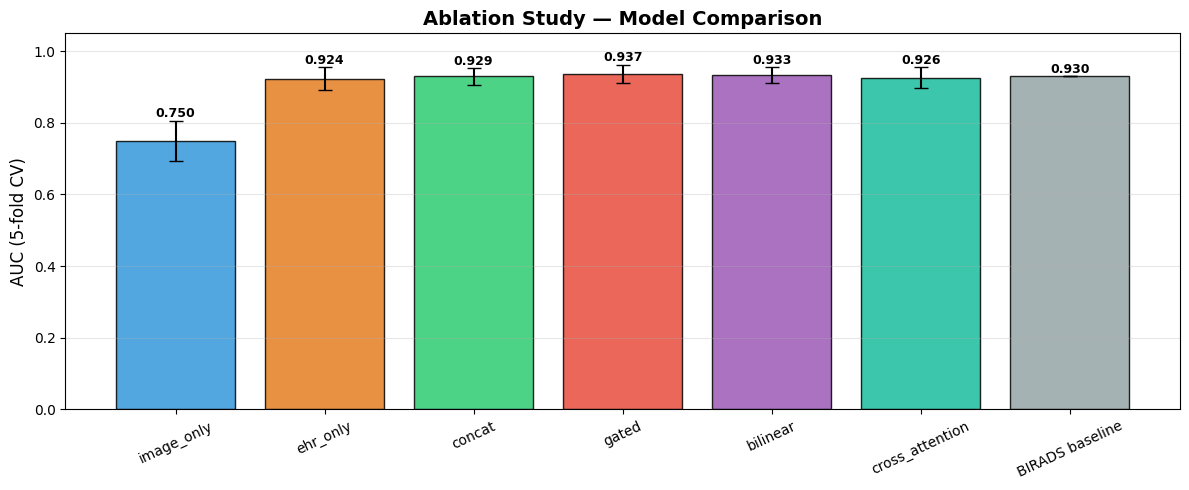

In [17]:
# ============================================================
# 10) BAR CHART — AUC COMPARISON ACROSS ALL MODELS
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))

model_names = FUSION_MODES + ['BIRADS baseline']
auc_means = [np.mean(results[m]['auc']) for m in FUSION_MODES] + [birads_auc]
auc_stds  = [np.std(results[m]['auc'])  for m in FUSION_MODES] + [0.0]

colors = [MODE_COLORS[m] for m in FUSION_MODES] + ['#95a5a6']
bars = ax.bar(model_names, auc_means, yerr=auc_stds, capsize=5,
              color=colors, edgecolor='black', alpha=0.85)

for bar, m, s in zip(bars, auc_means, auc_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.01,
            f'{m:.3f}', ha='center', fontweight='bold', fontsize=9)

ax.set_ylabel('AUC (5-fold CV)', fontsize=12)
ax.set_title('Ablation Study — Model Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/ablation_auc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

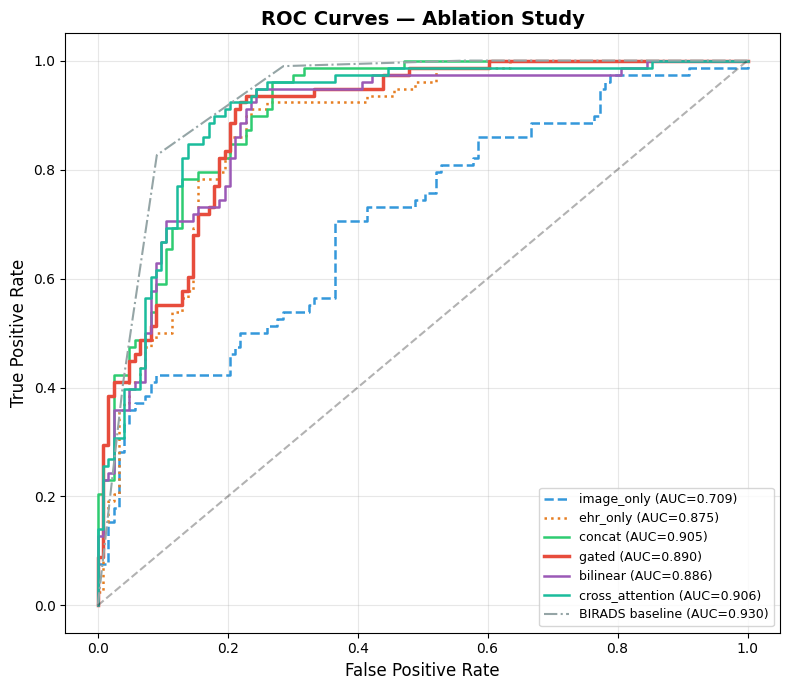

In [23]:
# ============================================================
# 11) ROC CURVES — ALL MODELS (pooled across folds)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))

line_styles = {'image_only': '--', 'ehr_only': ':', 'concat': '-',
               'gated': '-', 'bilinear': '-', 'cross_attention': '-'}

for mode in FUSION_MODES:
    all_p = np.concatenate([fp['probs'] for fp in fold_predictions[mode]])
    all_l = np.concatenate([fp['labels'] for fp in fold_predictions[mode]])
    fpr, tpr, _ = roc_curve(all_l, all_p)
    auc_val = roc_auc_score(all_l, all_p)
    lw = 2.5 if mode == best_mode else 1.8
    ax.plot(fpr, tpr, ls=line_styles[mode], color=MODE_COLORS[mode],
            lw=lw, label=f'{mode} (AUC={auc_val:.3f})')

# BIRADS ROC
fpr_b, tpr_b, _ = roc_curve(all_labels, birads_probs)
ax.plot(fpr_b, tpr_b, ls='-.', color='#95a5a6', lw=1.5,
        label=f'BIRADS baseline (AUC={birads_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Ablation Study', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/roc_curves_ablation.png', dpi=300, bbox_inches='tight')
plt.show()

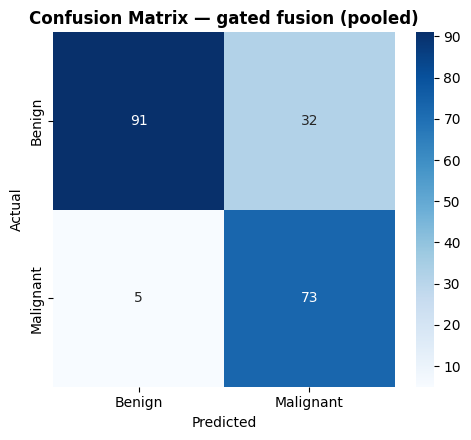


Classification Report (pooled across folds):
              precision    recall  f1-score   support

      Benign       0.95      0.74      0.83       123
   Malignant       0.70      0.94      0.80        78

    accuracy                           0.82       201
   macro avg       0.82      0.84      0.81       201
weighted avg       0.85      0.82      0.82       201



In [19]:
# ============================================================
# 12) CONFUSION MATRIX — BEST MODEL (auto-selected)
# ============================================================
all_p = np.concatenate([fp['probs'] for fp in fold_predictions[best_mode]])
all_l = np.concatenate([fp['labels'] for fp in fold_predictions[best_mode]])
all_pred = (all_p >= 0.5).astype(int)

cm = confusion_matrix(all_l, all_pred)
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_mode} fusion (pooled)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/confusion_matrix_{best_mode}.png',
            dpi=300, bbox_inches='tight')
plt.show()

print('\nClassification Report (pooled across folds):')
print(classification_report(all_l, all_pred,
                            target_names=['Benign', 'Malignant']))

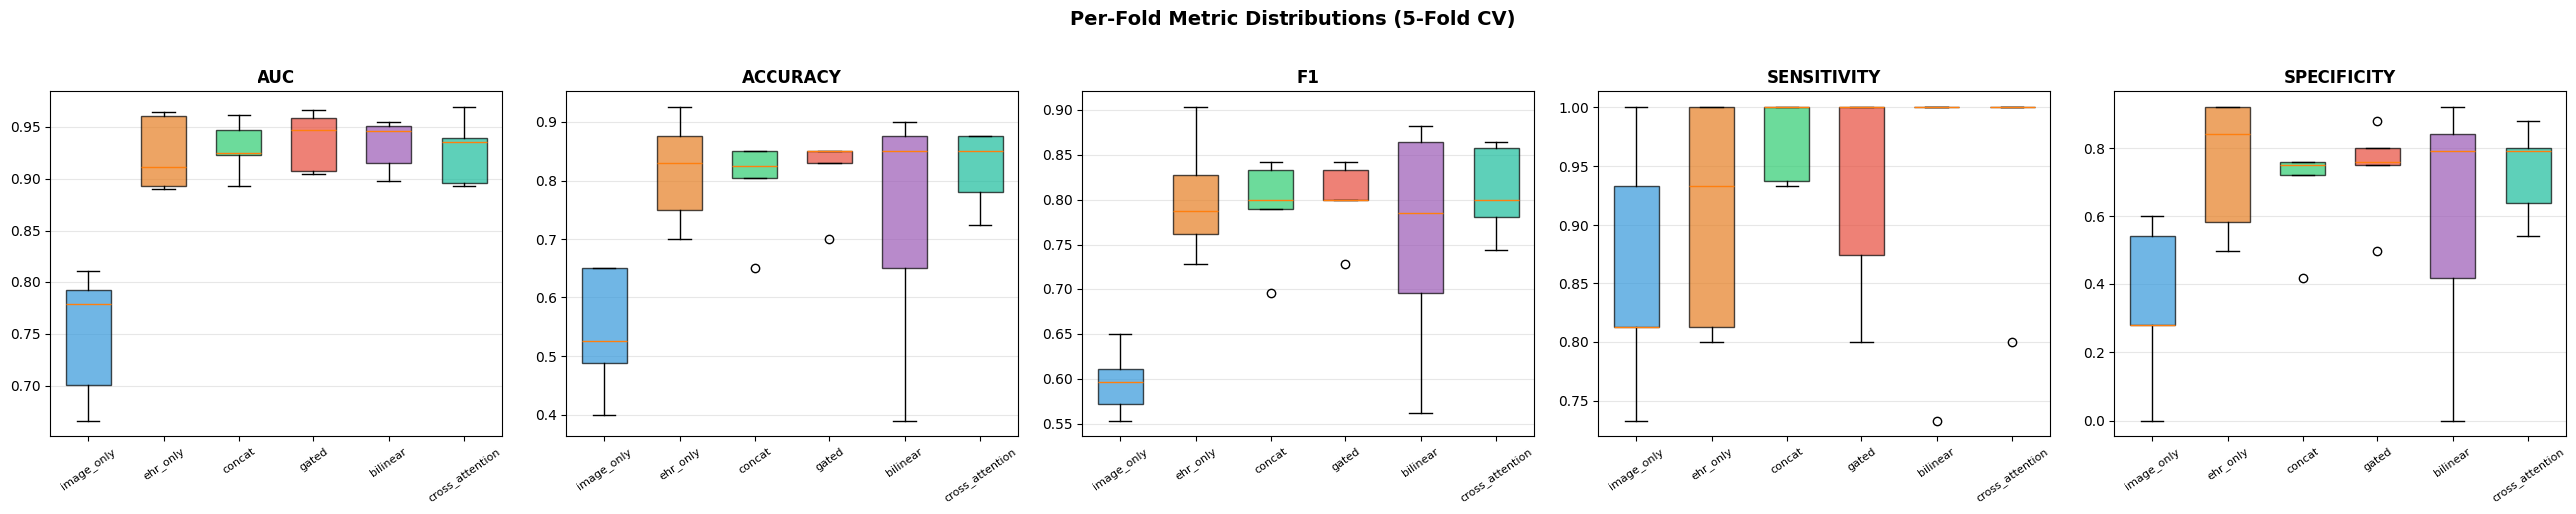

In [20]:
# ============================================================
# 13) PER-FOLD METRIC BOX PLOTS
# ============================================================
metrics_to_plot = ['auc', 'accuracy', 'f1', 'sensitivity', 'specificity']
fig, axes = plt.subplots(1, 5, figsize=(26, 5))

box_colors = [MODE_COLORS[m] for m in FUSION_MODES]

for ax, metric in zip(axes, metrics_to_plot):
    data = [results[mode][metric] for mode in FUSION_MODES]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6,
                    labels=FUSION_MODES)
    for patch, c in zip(bp['boxes'], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_title(metric.upper(), fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=35, labelsize=8)

plt.suptitle('Per-Fold Metric Distributions (5-Fold CV)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/fold_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

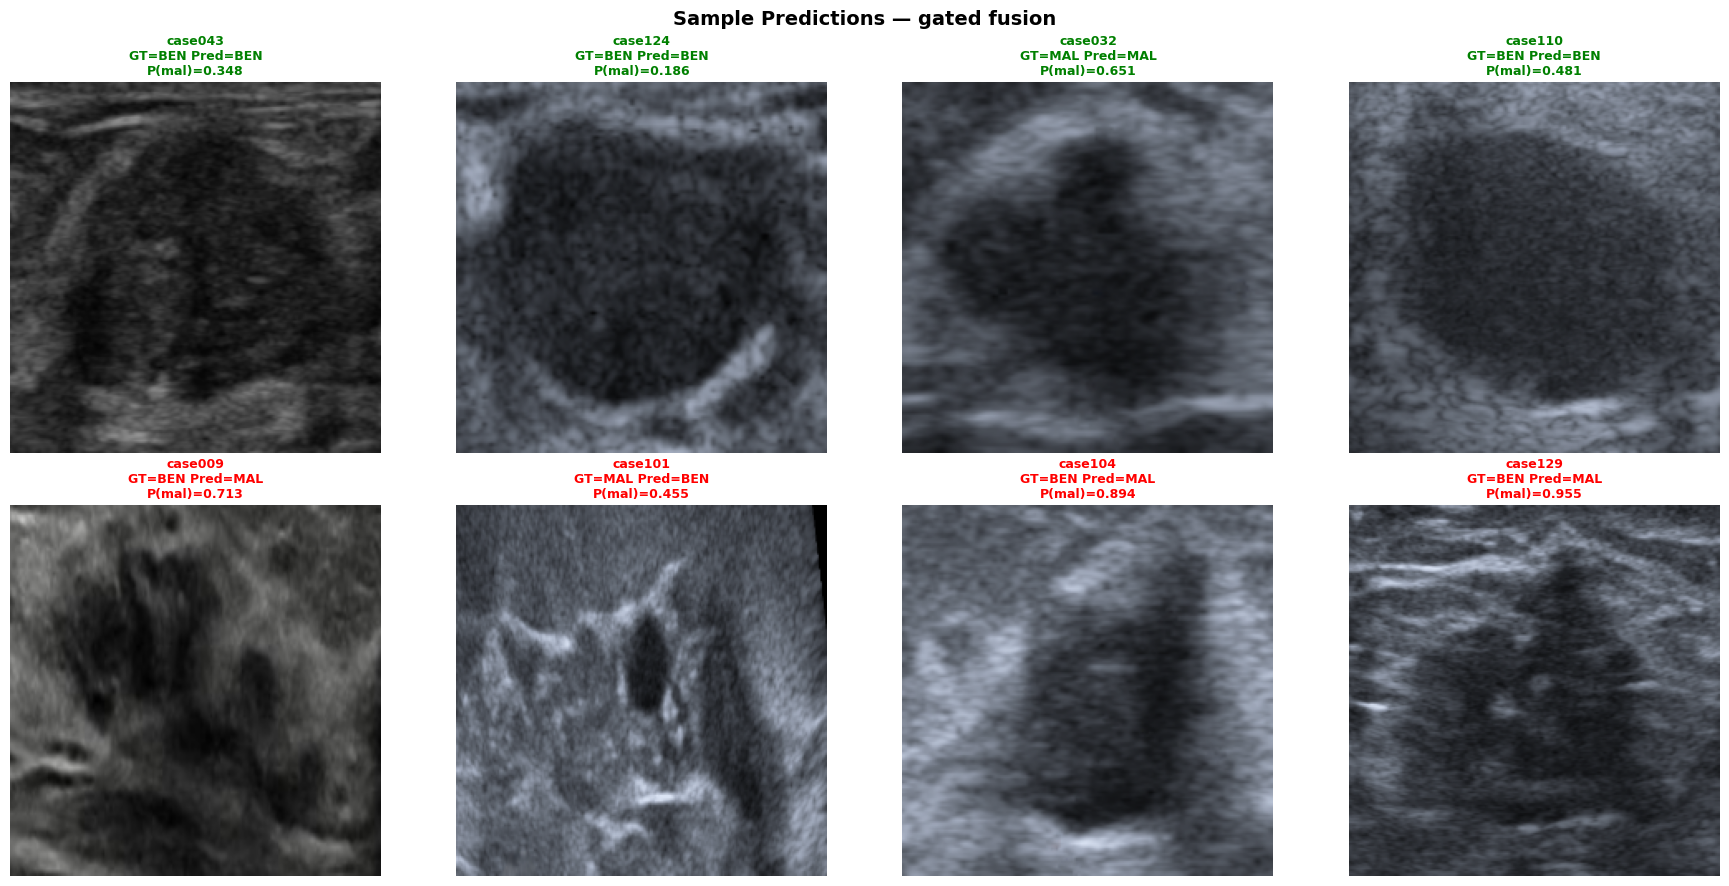

In [21]:
# ============================================================
# 14) SAMPLE ROI VISUALISATION — CORRECT & MISCLASSIFIED
# ============================================================
best_preds_all = []
for fp in fold_predictions[best_mode]:
    for cid, prob, lbl in zip(fp['cids'], fp['probs'], fp['labels']):
        best_preds_all.append({
            'cid': cid, 'prob': prob, 'label': int(lbl),
            'pred': int(prob >= 0.5), 'correct': int(prob >= 0.5) == int(lbl)
        })

pred_df = pd.DataFrame(best_preds_all)
correct = pred_df[pred_df['correct']].sample(min(4, pred_df['correct'].sum()),
                                              random_state=SEED)
wrong   = pred_df[~pred_df['correct']]
show    = pd.concat([correct, wrong.head(4)])

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax_row, (title, sub_df) in zip(axes, [('Correct', correct),
                                           ('Misclassified', wrong.head(4))]):
    for j, (_, r) in enumerate(sub_df.iterrows()):
        if j >= 4: break
        ax = ax_row[j]
        img = np.array(Image.open(
            os.path.join(DATA_DIR, f"{r['cid']}.png")).convert('RGB'))
        msk = np.array(Image.open(
            os.path.join(DATA_DIR, f"{r['cid']}_tumor.png")).convert('L'))
        msk = (msk > 0).astype(np.uint8)
        roi = extract_roi(img, msk)
        ax.imshow(roi)
        gt_txt  = 'MAL' if r['label'] else 'BEN'
        pr_txt  = 'MAL' if r['pred']  else 'BEN'
        color = 'green' if r['correct'] else 'red'
        ax.set_title(f"{r['cid']}\nGT={gt_txt} Pred={pr_txt}\n"
                     f"P(mal)={r['prob']:.3f}",
                     fontsize=9, color=color, fontweight='bold')
        ax.axis('off')
    for j in range(len(sub_df), 4):
        ax_row[j].axis('off')

plt.suptitle(f'Sample Predictions — {best_mode} fusion',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/sample_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# ============================================================
# 15) SAVE ALL RESULTS
# ============================================================
# Per-sample pooled predictions
pred_df.to_csv(f'{WORK_DIR}/classification_predictions.csv', index=False)

# Full results dict
with open(f'{WORK_DIR}/classification_results.pkl', 'wb') as f:
    pickle.dump({
        'results': results,
        'fold_predictions': fold_predictions,
        'birads_baseline': {
            'auc': birads_auc, 'acc': birads_acc,
            'f1': birads_f1, 'sens': birads_sens, 'spec': birads_spec
        },
        'config': {
            'n_folds': N_FOLDS, 'batch_size': BATCH_SIZE,
            'lr': LR, 'epochs': EPOCHS, 'patience': PATIENCE,
            'backbone': 'MedSAM ViT-B (frozen, mask-guided avg pooling)',
            'sam_feat_dim': SAM_FEAT_DIM,
            'img_out': IMG_OUT_DIM, 'ehr_hidden': EHR_DIM,
            'ehr_out': EHR_DIM, 'dropout': DROPOUT,
        }
    }, f)

print('All results saved to:')
print(f'  {WORK_DIR}/ablation_results.csv')
print(f'  {WORK_DIR}/classification_predictions.csv')
print(f'  {WORK_DIR}/classification_results.pkl')

All results saved to:
  /kaggle/working/ablation_results.csv
  /kaggle/working/classification_predictions.csv
  /kaggle/working/classification_results.pkl


In [22]:
# ============================================================
# 16) STATISTICAL ANALYSIS — Bootstrap CIs + Pairwise Tests
# ============================================================

# ── Pool predictions per mode ──
pooled = {}
for mode in FUSION_MODES:
    pooled[mode] = {
        'probs':  np.concatenate([fp['probs']  for fp in fold_predictions[mode]]),
        'labels': np.concatenate([fp['labels'] for fp in fold_predictions[mode]]),
    }

# ── Bootstrap AUC confidence intervals ──
def bootstrap_auc_ci(y_true, y_prob, n_boot=2000, ci=0.95, seed=SEED):
    rng = np.random.RandomState(seed)
    aucs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    alpha = (1 - ci) / 2
    return np.percentile(aucs, [alpha * 100, (1 - alpha) * 100])

# ── Bootstrap paired AUC comparison ──
def bootstrap_paired_pvalue(y_true, probs_a, probs_b, n_boot=5000, seed=SEED):
    """Two-sided bootstrap test: H0: AUC(A) == AUC(B)."""
    rng = np.random.RandomState(seed)
    diffs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        auc_a = roc_auc_score(y_true[idx], probs_a[idx])
        auc_b = roc_auc_score(y_true[idx], probs_b[idx])
        diffs.append(auc_a - auc_b)
    diffs = np.array(diffs)
    p = 2 * min((diffs >= 0).mean(), (diffs <= 0).mean())
    return max(p, 1.0 / len(diffs))

# ── Results table ──
print('STATISTICAL ANALYSIS')
print('=' * 85)
print(f'{"Model":<18} {"AUC":>8}  {"95% Bootstrap CI":>20}  {"p vs best":>12}')
print('-' * 85)

best_p = pooled[best_mode]

for mode in FUSION_MODES:
    p = pooled[mode]
    auc_val = roc_auc_score(p['labels'], p['probs'])
    ci_lo, ci_hi = bootstrap_auc_ci(p['labels'], p['probs'])
    if mode == best_mode:
        p_str = '(reference)'
    else:
        pv = bootstrap_paired_pvalue(best_p['labels'], best_p['probs'], p['probs'])
        p_str = f'{pv:.4f}' + (' *' if pv < 0.05 else '')
    print(f'{mode:<18} {auc_val:>8.4f}  [{ci_lo:.4f}, {ci_hi:.4f}]  {p_str:>12}')

# BIRADS baseline
ci_lo_b, ci_hi_b = bootstrap_auc_ci(all_labels, birads_probs)
pv_b = bootstrap_paired_pvalue(all_labels, best_p['probs'],
                               birads_probs[:len(best_p['probs'])])
print(f'{"BIRADS baseline":<18} {birads_auc:>8.4f}  '
      f'[{ci_lo_b:.4f}, {ci_hi_b:.4f}]  {pv_b:.4f}')

print('=' * 85)
print(f'★ Best model: {best_mode}  |  * = p < 0.05 (significantly different)')

# ── Paired Wilcoxon signed-rank test on per-fold AUCs ──
print(f'\nWilcoxon signed-rank test (per-fold AUCs, {best_mode} vs others):')
print('-' * 60)
for mode in FUSION_MODES:
    if mode == best_mode:
        continue
    best_aucs = np.array(results[best_mode]['auc'])
    other_aucs = np.array(results[mode]['auc'])
    diff = best_aucs - other_aucs
    if np.all(diff == 0):
        print(f'  {best_mode} vs {mode}: identical values, test not applicable')
    else:
        try:
            stat, p = wilcoxon(best_aucs, other_aucs)
            sig = ' *' if p < 0.05 else ''
            print(f'  {best_mode} vs {mode}: W={stat:.1f}, p={p:.4f}{sig}')
        except Exception as e:
            print(f'  {best_mode} vs {mode}: {e}')

STATISTICAL ANALYSIS
Model                   AUC      95% Bootstrap CI     p vs best
-------------------------------------------------------------------------------------
image_only           0.7087  [0.6307, 0.7839]      0.0002 *
ehr_only             0.8745  [0.8239, 0.9197]        0.3536
concat               0.9054  [0.8653, 0.9416]        0.3080
gated                0.8902  [0.8457, 0.9310]   (reference)
bilinear             0.8860  [0.8387, 0.9323]        0.8104
cross_attention      0.9061  [0.8626, 0.9453]        0.4060


IndexError: index 210 is out of bounds for axis 0 with size 201

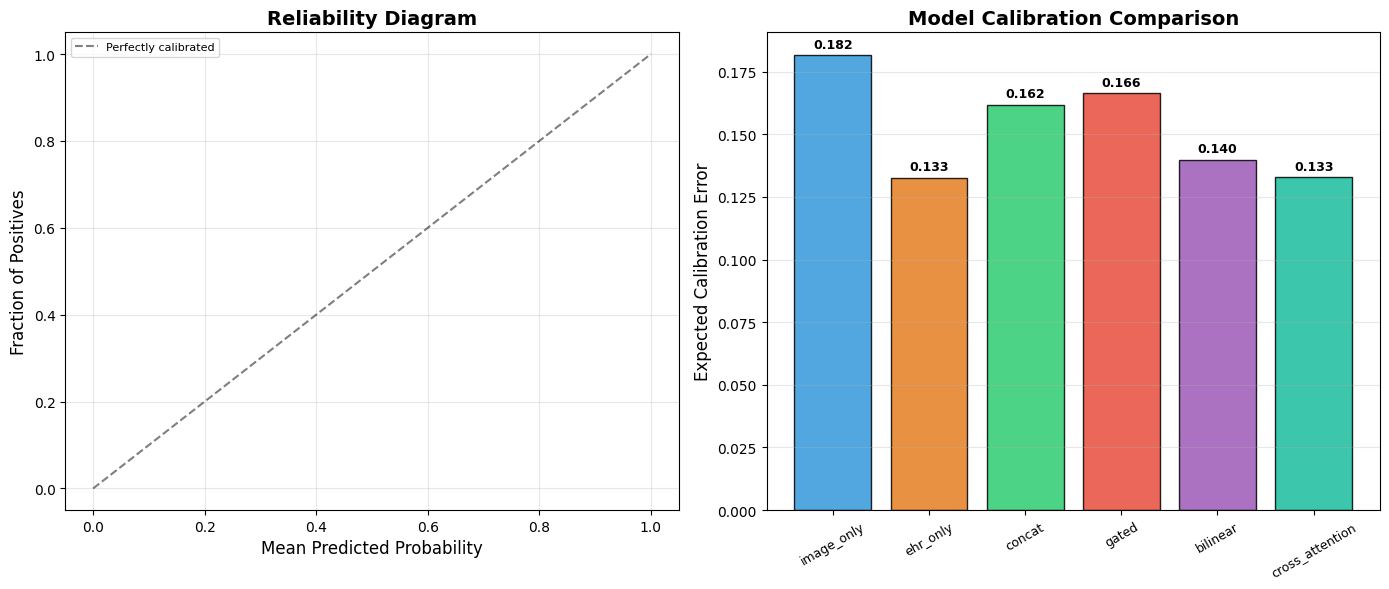


ECE Summary:
  image_only         ECE = 0.1816
  ehr_only           ECE = 0.1327 ← best calibrated
  concat             ECE = 0.1617
  gated              ECE = 0.1663
  bilinear           ECE = 0.1399
  cross_attention    ECE = 0.1329


In [24]:
# ============================================================
# 17) CALIBRATION ANALYSIS — Reliability Diagram + ECE
# ============================================================

def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Expected Calibration Error (ECE)."""
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bin_edges[i]) & (y_prob < bin_edges[i + 1])
        if mask.sum() == 0:
            continue
        ece += mask.sum() / len(y_prob) * abs(
            y_true[mask].mean() - y_prob[mask].mean())
    return ece

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Reliability diagram ──
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfectly calibrated')
for mode in FUSION_MODES:
    p = pooled[mode]
    try:
        frac_pos, mean_pred = calibration_curve(
            p['labels'], p['probs'], n_bins=8, strategy='uniform')
        ax.plot(mean_pred, frac_pos, marker='o',
                color=MODE_COLORS[mode], label=mode, alpha=0.8)
    except Exception:
        pass
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Reliability Diagram', fontsize=14, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3)

# ── Right: ECE bar chart ──
ax = axes[1]
ece_vals = []
for mode in FUSION_MODES:
    p = pooled[mode]
    ece_vals.append(expected_calibration_error(p['labels'], p['probs']))
colors_ece = [MODE_COLORS[m] for m in FUSION_MODES]
bars = ax.bar(FUSION_MODES, ece_vals, color=colors_ece, alpha=0.85,
              edgecolor='black')
for bar, ece in zip(bars, ece_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{ece:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Expected Calibration Error', fontsize=12)
ax.set_title('Model Calibration Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=30, labelsize=9)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/calibration_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nECE Summary:')
for mode, ece in zip(FUSION_MODES, ece_vals):
    star = ' ← best calibrated' if ece == min(ece_vals) else ''
    print(f'  {mode:<18s} ECE = {ece:.4f}{star}')

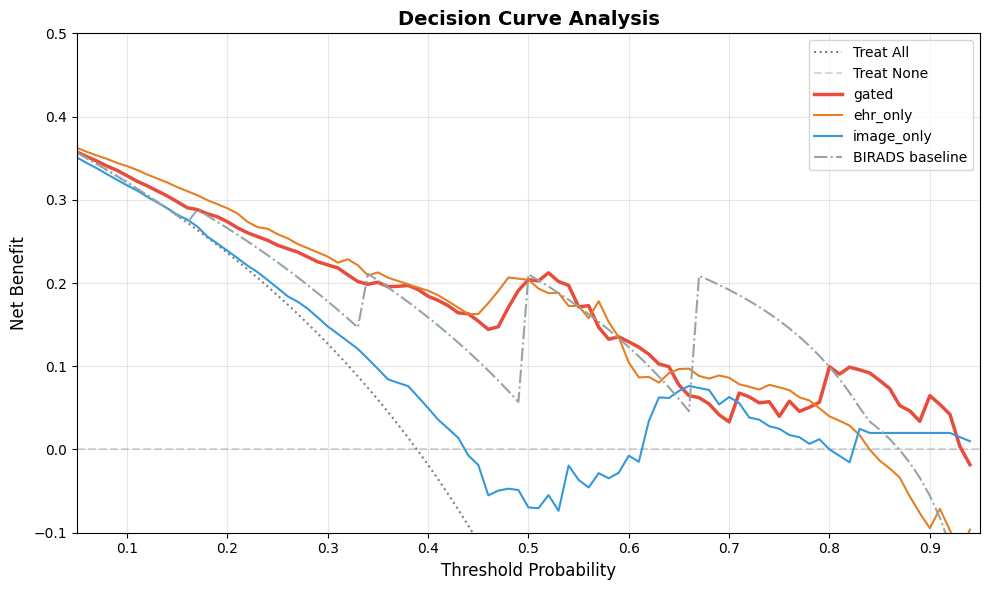

Prevalence: 0.389  |  Best model: gated


In [25]:
# ============================================================
# 18) DECISION CURVE ANALYSIS — Net Clinical Benefit
# ============================================================

def net_benefit(y_true, y_prob, threshold):
    """Net benefit at a given threshold."""
    preds = (y_prob >= threshold).astype(int)
    tp = ((preds == 1) & (y_true == 1)).sum()
    fp = ((preds == 1) & (y_true == 0)).sum()
    n = len(y_true)
    return tp / n - fp / n * (threshold / (1 - threshold + 1e-10))

thresholds = np.arange(0.05, 0.95, 0.01)

fig, ax = plt.subplots(figsize=(10, 6))

# Treat-all / treat-none reference
prevalence = all_labels.mean()
treat_all = [prevalence - (1 - prevalence) * (t / (1 - t + 1e-10))
             for t in thresholds]
ax.plot(thresholds, treat_all, 'k:', alpha=0.5, label='Treat All')
ax.axhline(0, color='gray', ls='--', alpha=0.3, label='Treat None')

# Key models
for mode in [best_mode, 'ehr_only', 'image_only']:
    p = pooled[mode]
    nbs = [net_benefit(p['labels'], p['probs'], t) for t in thresholds]
    lw = 2.5 if mode == best_mode else 1.5
    ax.plot(thresholds, nbs, lw=lw, color=MODE_COLORS[mode], label=mode)

# BIRADS
nbs_b = [net_benefit(all_labels, birads_probs, t) for t in thresholds]
ax.plot(thresholds, nbs_b, ls='-.', color='#95a5a6', lw=1.5,
        label='BIRADS baseline')

ax.set_xlabel('Threshold Probability', fontsize=12)
ax.set_ylabel('Net Benefit', fontsize=12)
ax.set_title('Decision Curve Analysis', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(0.05, 0.95)
ax.set_ylim(-0.1, max(0.5, prevalence + 0.1))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/decision_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Prevalence: {prevalence:.3f}  |  Best model: {best_mode}')

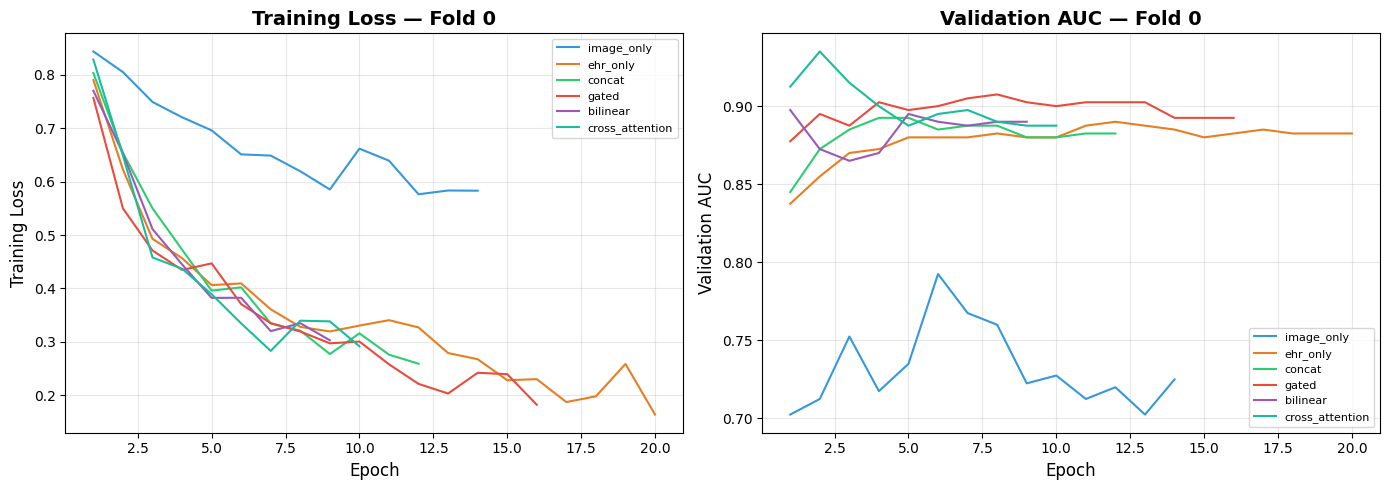

In [26]:
# ============================================================
# 19) TRAINING CONVERGENCE CURVES (Fold 0)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Training loss
ax = axes[0]
for mode in FUSION_MODES:
    tc = training_curves[mode]
    if len(tc['epoch']) > 0:
        ax.plot(tc['epoch'], tc['train_loss'], color=MODE_COLORS[mode],
                lw=1.5, label=mode)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Training Loss — Fold 0', fontsize=14, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Right: Validation AUC
ax = axes[1]
for mode in FUSION_MODES:
    tc = training_curves[mode]
    if len(tc['epoch']) > 0:
        ax.plot(tc['epoch'], tc['val_auc'], color=MODE_COLORS[mode],
                lw=1.5, label=mode)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Validation AUC', fontsize=12)
ax.set_title('Validation AUC — Fold 0', fontsize=14, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
# ============================================================
# 16) TRIAGE ENGINE — rule-based clinical decision support
# ============================================================

# --- Configurable thresholds ---
TRIAGE_LOW  = 0.30   # below this → lean toward "routine"
TRIAGE_HIGH = 0.70   # above this → lean toward "biopsy"

BIRADS_ORDER = {'1': 0, '2': 1, '3': 2, '4a': 3, '4b': 4, '4c': 5, '5': 6}

# Colour / label mapping
TRIAGE_COLOURS = {
    'Routine':    '#2ecc71',   # green
    'Follow-up':  '#f39c12',   # amber
    'Biopsy':     '#e74c3c',   # red
}
TRIAGE_LABELS  = list(TRIAGE_COLOURS.keys())
TRIAGE_ACTIONS = {
    'Routine':   'Regular screening follow-up in 12 months.',
    'Follow-up': 'Short-interval imaging follow-up in 6 months.',
    'Biopsy':    'Tissue sampling / specialist referral recommended.',
}


def triage_decision(p_mal, birads_str,
                    t_low=TRIAGE_LOW, t_high=TRIAGE_HIGH):
    """
    Conservative rule-based triage combining model P(malignant)
    and ACR BIRADS category.

    Returns
    -------
    level      : str   – 'Routine' | 'Follow-up' | 'Biopsy'
    discordant : bool  – True when model and BIRADS clearly disagree
    rationale  : str   – human-readable explanation
    """
    b = BIRADS_ORDER.get(birads_str, 3)

    # --- Risk buckets ---
    model_risk  = ('low' if p_mal < t_low
                   else 'high' if p_mal >= t_high
                   else 'moderate')
    birads_risk = ('low' if b <= 2
                   else 'high' if b >= 4
                   else 'moderate')          # BIRADS 3

    # --- Discordance flag ---
    discordant = ((model_risk == 'high' and birads_risk == 'low') or
                  (model_risk == 'low'  and birads_risk == 'high'))

    # --- Conservative triage (never under-triages) ---
    if model_risk == 'high' or b >= 4:
        level = 'Biopsy'
    elif model_risk == 'moderate' or b == 3 or discordant:
        level = 'Follow-up'
    else:
        level = 'Routine'

    # --- Build rationale string ---
    parts = [f"P(mal)={p_mal:.2f}", f"BIRADS {birads_str}"]
    if discordant:
        parts.append("⚠ DISCORDANT — senior radiologist review")
    rationale = ' · '.join(parts)

    return level, discordant, rationale


# --- Quick smoke test ---
for _p, _b in [(0.12, '2'), (0.45, '3'), (0.85, '4c'),
               (0.10, '5'), (0.90, '2')]:
    lvl, disc, rat = triage_decision(_p, _b)
    tag = ' [DISC]' if disc else ''
    print(f"  P={_p:.2f}  BIRADS={_b}  →  {lvl}{tag}   | {rat}")

print('\nTriage engine defined ✓')

  P=0.12  BIRADS=2  →  Routine   | P(mal)=0.12 · BIRADS 2
  P=0.45  BIRADS=3  →  Follow-up   | P(mal)=0.45 · BIRADS 3
  P=0.85  BIRADS=4c  →  Biopsy   | P(mal)=0.85 · BIRADS 4c
  P=0.10  BIRADS=5  →  Biopsy [DISC]   | P(mal)=0.10 · BIRADS 5 · ⚠ DISCORDANT — senior radiologist review
  P=0.90  BIRADS=2  →  Biopsy [DISC]   | P(mal)=0.90 · BIRADS 2 · ⚠ DISCORDANT — senior radiologist review

Triage engine defined ✓


Triage Distribution (using gated fusion)
  Routine     :   24  ( 11.9%)   [0 discordant]
  Follow-up   :   65  ( 32.3%)   [0 discordant]
  Biopsy      :  112  ( 55.7%)   [2 discordant]
  TOTAL       :  201

  Discordant cases overall: 2  (1.0%)


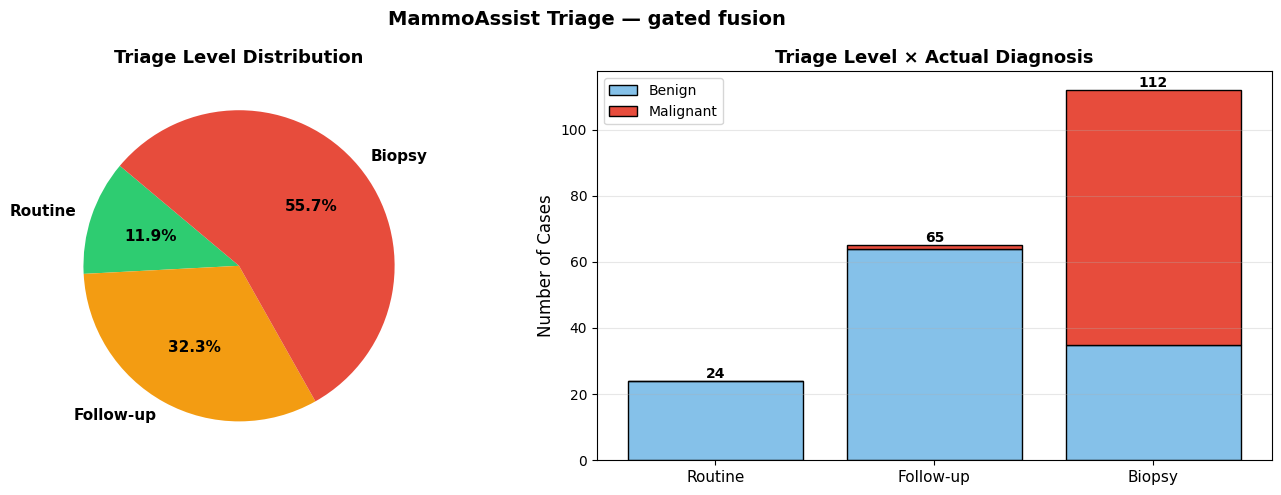

In [28]:
# ============================================================
# 21) APPLY TRIAGE TO ALL PREDICTIONS (pooled from best model)
# ============================================================
triage_records = []

for fp in fold_predictions[best_mode]:
    for cid, prob, lbl in zip(fp['cids'], fp['probs'], fp['labels']):
        birads_str = feature_records[cid]['birads']
        level, disc, rationale = triage_decision(prob, birads_str)
        triage_records.append({
            'case_id':     cid,
            'p_malignant': prob,
            'pred_label':  int(prob >= 0.5),
            'true_label':  int(lbl),
            'birads':      birads_str,
            'triage':      level,
            'discordant':  disc,
            'rationale':   rationale,
        })

triage_df = pd.DataFrame(triage_records).sort_values('case_id').reset_index(drop=True)

# --- Distribution summary ---
print(f'Triage Distribution (using {best_mode} fusion)')
print('=' * 50)
for lvl in TRIAGE_LABELS:
    n  = (triage_df['triage'] == lvl).sum()
    nd = ((triage_df['triage'] == lvl) & triage_df['discordant']).sum()
    print(f"  {lvl:12s}:  {n:3d}  ({n/len(triage_df)*100:5.1f}%)"
          f"   [{nd} discordant]")
print(f"  {'TOTAL':12s}:  {len(triage_df):3d}")
disc_total = triage_df['discordant'].sum()
print(f"\n  Discordant cases overall: {disc_total}  "
      f"({disc_total/len(triage_df)*100:.1f}%)")

# --- Pie chart + stacked bar ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = [((triage_df['triage'] == lvl).sum()) for lvl in TRIAGE_LABELS]
colors = [TRIAGE_COLOURS[l] for l in TRIAGE_LABELS]
axes[0].pie(counts, labels=TRIAGE_LABELS, colors=colors,
            autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title('Triage Level Distribution', fontsize=13, fontweight='bold')

for i, lvl in enumerate(TRIAGE_LABELS):
    sub = triage_df[triage_df['triage'] == lvl]
    n_ben = (sub['true_label'] == 0).sum()
    n_mal = (sub['true_label'] == 1).sum()
    axes[1].bar(i, n_ben, color='#85c1e9', edgecolor='black',
                label='Benign' if i == 0 else '')
    axes[1].bar(i, n_mal, bottom=n_ben, color='#e74c3c',
                edgecolor='black', label='Malignant' if i == 0 else '')
    axes[1].text(i, n_ben + n_mal + 1, f'{n_ben+n_mal}',
                 ha='center', fontweight='bold')

axes[1].set_xticks(range(len(TRIAGE_LABELS)))
axes[1].set_xticklabels(TRIAGE_LABELS, fontsize=11)
axes[1].set_ylabel('Number of Cases', fontsize=12)
axes[1].set_title('Triage Level × Actual Diagnosis', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(f'MammoAssist Triage — {best_mode} fusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/triage_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

TRIAGE SAFETY REPORT

  ┌─ ROUTINE (24 cases) ──────────────────────
  │  Benign:      24   (100.0%)
  │  Malignant:    0   (0.0%)
  │  Avg P(mal): 0.156
  │  Discordant: 0
  └────────────────────────────────────────────

  ┌─ FOLLOW-UP (65 cases) ──────────────────────
  │  Benign:      64   (98.5%)
  │  Malignant:    1   (1.5%)
  │  Avg P(mal): 0.345
  │  Discordant: 0
  └────────────────────────────────────────────

  ┌─ BIOPSY (112 cases) ──────────────────────
  │  Benign:      35   (31.2%)
  │  Malignant:   77   (68.8%)
  │  Avg P(mal): 0.706
  │  Discordant: 2
  └────────────────────────────────────────────

  Total malignant cases:           78
  Correctly escalated (Biopsy):    77  (98.7%)
  Caught in Follow-up:             1  (1.3%)
  Missed (Routine):                0  (0.0%)
  Triage Sensitivity (non-Routine):100.0%

  Model–BIRADS agreement: 154/201  (76.6%)


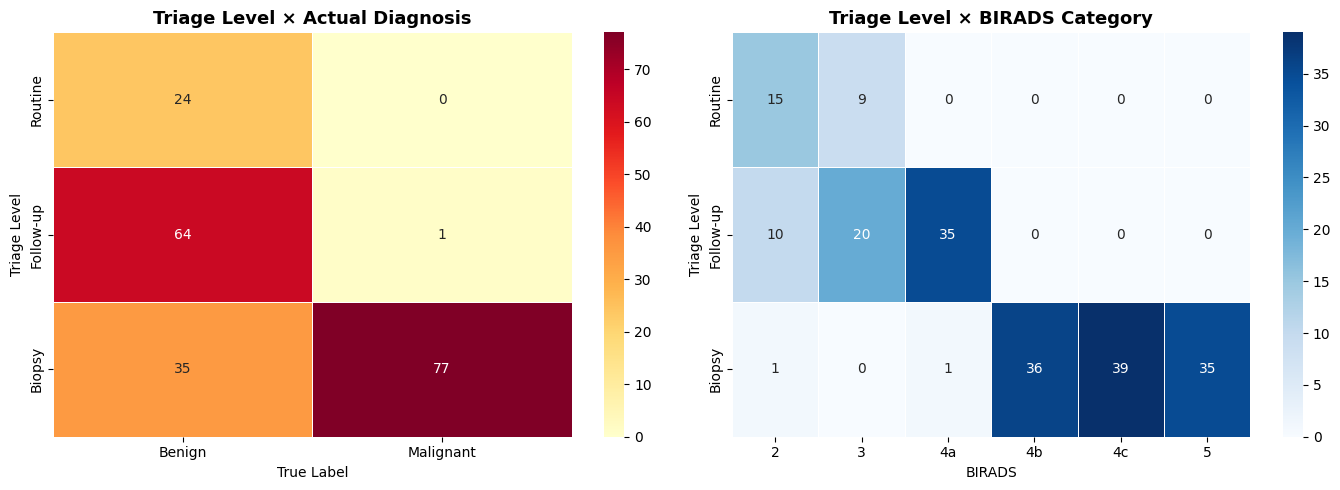

In [29]:
# ============================================================
# 18) TRIAGE SAFETY ANALYSIS
#     Key clinical question: does any malignant case get
#     triaged as "Routine" (i.e. missed)?
# ============================================================

print('TRIAGE SAFETY REPORT')
print('=' * 70)

for lvl in TRIAGE_LABELS:
    sub = triage_df[triage_df['triage'] == lvl]
    n = len(sub)
    if n == 0:
        print(f"\n  {lvl}: 0 cases")
        continue

    n_mal  = (sub['true_label'] == 1).sum()
    n_ben  = (sub['true_label'] == 0).sum()
    mal_pct = n_mal / max(n, 1) * 100

    print(f"\n  ┌─ {lvl.upper()} ({n} cases) ──────────────────────")
    print(f"  │  Benign:     {n_ben:3d}   ({100 - mal_pct:.1f}%)")
    print(f"  │  Malignant:  {n_mal:3d}   ({mal_pct:.1f}%)")
    print(f"  │  Avg P(mal): {sub['p_malignant'].mean():.3f}")
    print(f"  │  Discordant: {sub['discordant'].sum()}")
    if lvl == 'Routine' and n_mal > 0:
        print(f"  │  ⚠ {n_mal} MALIGNANT case(s) triaged as Routine!")
        missed = sub[sub['true_label'] == 1]
        for _, row in missed.iterrows():
            print(f"  │     {row['case_id']}  P={row['p_malignant']:.3f}  "
                  f"BIRADS={row['birads']}")
    print(f"  └────────────────────────────────────────────")

# --- Critical safety metrics ---
total_mal   = (triage_df['true_label'] == 1).sum()
mal_biopsy  = ((triage_df['triage'] == 'Biopsy')  & (triage_df['true_label'] == 1)).sum()
mal_followup= ((triage_df['triage'] == 'Follow-up')& (triage_df['true_label'] == 1)).sum()
mal_routine = ((triage_df['triage'] == 'Routine') & (triage_df['true_label'] == 1)).sum()

triage_sens = (mal_biopsy + mal_followup) / max(total_mal, 1)  # caught = not Routine

print(f"\n{'='*70}")
print(f"  Total malignant cases:           {total_mal}")
print(f"  Correctly escalated (Biopsy):    {mal_biopsy}  "
      f"({mal_biopsy/max(total_mal,1)*100:.1f}%)")
print(f"  Caught in Follow-up:             {mal_followup}  "
      f"({mal_followup/max(total_mal,1)*100:.1f}%)")
print(f"  Missed (Routine):                {mal_routine}  "
      f"({mal_routine/max(total_mal,1)*100:.1f}%)")
print(f"  Triage Sensitivity (non-Routine):{triage_sens*100:.1f}%")
print(f"{'='*70}")

# --- Concordance: model pred vs BIRADS-alone pred ---
birads_pred = np.array([(BIRADS_ORDER[feature_records[c]['birads']] >= 3)
                         for c in triage_df['case_id']]).astype(int)
model_pred  = triage_df['pred_label'].values

agree = (birads_pred == model_pred).sum()
print(f"\n  Model–BIRADS agreement: {agree}/{len(triage_df)}  "
      f"({agree/len(triage_df)*100:.1f}%)")

# --- Heatmap: Triage × True Label ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Triage level × True label
ct = pd.crosstab(triage_df['triage'], triage_df['true_label'].map({0:'Benign', 1:'Malignant'}))
ct = ct.reindex(TRIAGE_LABELS)
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, linecolor='white')
axes[0].set_title('Triage Level × Actual Diagnosis', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Triage Level')
axes[0].set_xlabel('True Label')

# Right: Triage level × BIRADS
ct2 = pd.crosstab(triage_df['triage'], triage_df['birads'])
ct2 = ct2.reindex(TRIAGE_LABELS)
birads_cols = sorted(ct2.columns, key=lambda x: BIRADS_ORDER.get(x, 0))
ct2 = ct2[birads_cols]
sns.heatmap(ct2, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            linewidths=0.5, linecolor='white')
axes[1].set_title('Triage Level × BIRADS Category', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Triage Level')
axes[1].set_xlabel('BIRADS')

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/triage_safety_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

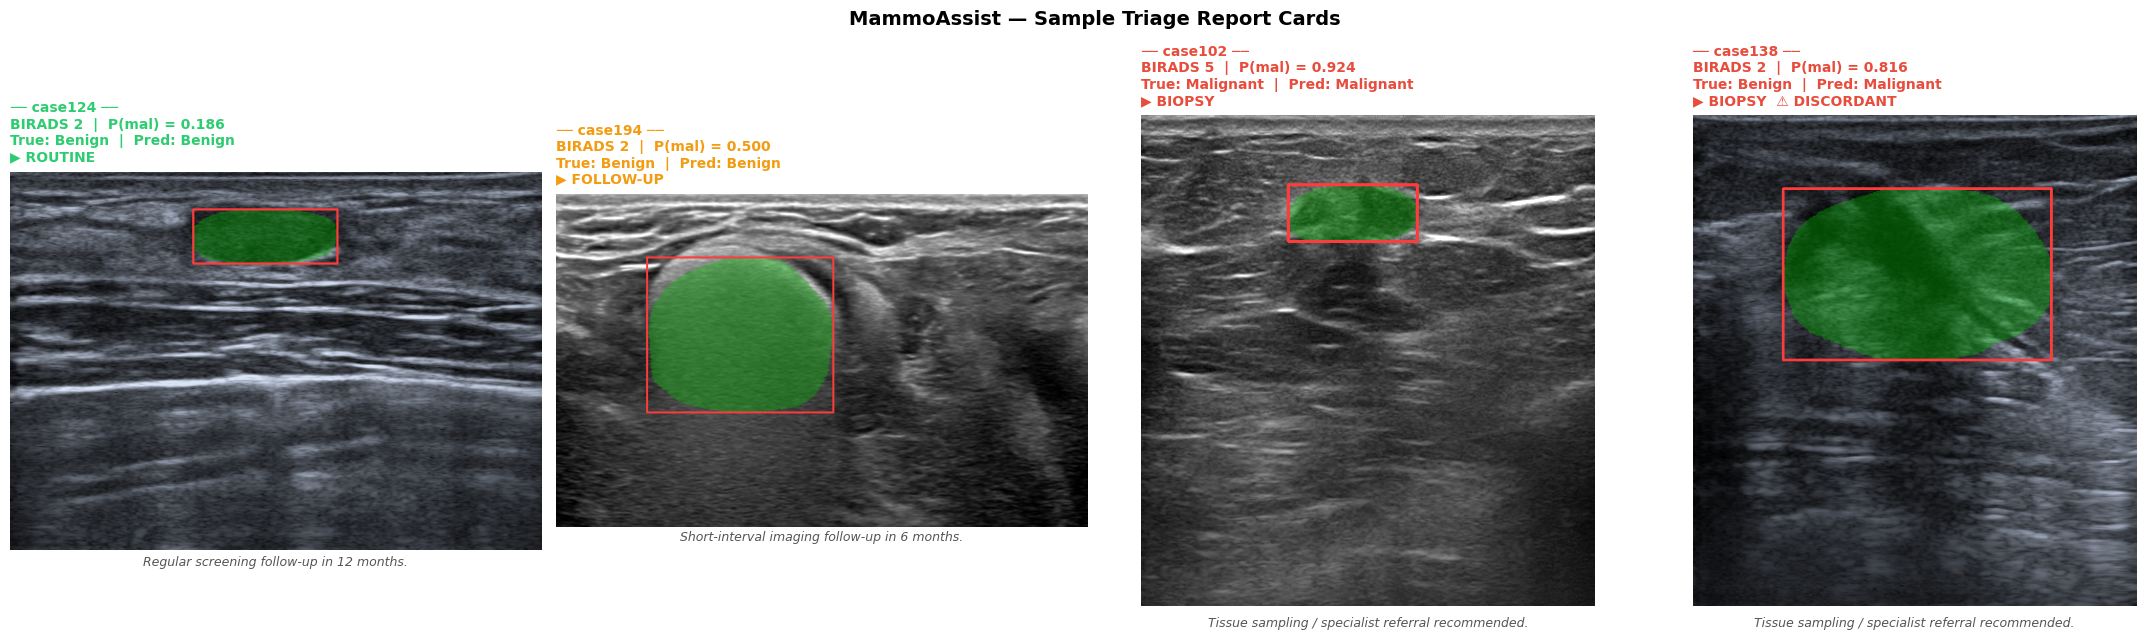

In [30]:
# ============================================================
# 19) SAMPLE TRIAGE REPORT CARDS  (clinical-style output)
# ============================================================

# Pick one case per triage level (+ a discordant example if available)
card_cases = []
for lvl in TRIAGE_LABELS:
    sub = triage_df[triage_df['triage'] == lvl]
    if len(sub) > 0:
        card_cases.append(sub.sample(1, random_state=SEED).iloc[0])

disc_cases = triage_df[triage_df['discordant']]
if len(disc_cases) > 0:
    card_cases.append(disc_cases.sample(1, random_state=SEED).iloc[0])

n_cards = len(card_cases)
fig, axes = plt.subplots(1, n_cards, figsize=(5.5 * n_cards, 6))
if n_cards == 1:
    axes = [axes]

for ax, row in zip(axes, card_cases):
    cid = row['case_id']

    # Load image + predicted mask overlay
    img = np.array(Image.open(
        os.path.join(DATA_DIR, f'{cid}.png')).convert('RGB'))
    p_msk = predicted_masks.get(cid)

    # Create overlay: green mask + red bounding box
    display = img.copy()
    if p_msk is not None and p_msk.sum() > 0:
        overlay = display.copy()
        overlay[p_msk > 0] = [0, 200, 0]
        display = cv2.addWeighted(display, 0.65, overlay, 0.35, 0)
        # Bbox
        ys, xs = np.where(p_msk > 0)
        cv2.rectangle(display,
                      (int(xs.min()), int(ys.min())),
                      (int(xs.max()), int(ys.max())),
                      (255, 60, 60), 2)

    ax.imshow(display)

    # Title block — styled like a clinical report card
    lvl_color = TRIAGE_COLOURS[row['triage']]
    disc_tag  = '  ⚠ DISCORDANT' if row['discordant'] else ''
    gt_str    = 'Malignant' if row['true_label'] else 'Benign'

    title_lines = (
        f"── {cid} ──\n"
        f"BIRADS {row['birads']}  |  P(mal) = {row['p_malignant']:.3f}\n"
        f"True: {gt_str}  |  Pred: {'Malignant' if row['pred_label'] else 'Benign'}\n"
        f"▶ {row['triage'].upper()}{disc_tag}"
    )
    ax.set_title(title_lines, fontsize=10, fontweight='bold',
                 color=lvl_color, loc='left', pad=8)

    # Action text at bottom
    ax.text(0.5, -0.04, TRIAGE_ACTIONS[row['triage']],
            transform=ax.transAxes, fontsize=9, ha='center',
            style='italic', color='#555555')
    ax.axis('off')

plt.suptitle('MammoAssist — Sample Triage Report Cards',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/triage_report_cards.png', dpi=300, bbox_inches='tight')
plt.show()